<a href="https://colab.research.google.com/github/s-ishaan/Apollo-Enrichment-Pipeline/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os

# # Path to the subfolder
# subfolder_path = "/content/drive/My Drive/image_captioning/Images"

# # List all files in the subfolder
# files = [f for f in os.listdir(subfolder_path) if os.path.isfile(os.path.join(subfolder_path, f))]

# # Count the number of files
# num_files = len(files)

# print(f"Number of files in '{subfolder_path}': {num_files}")


In [ ]:
file_path = "/content/drive/My Drive/image_captioning"

In [ ]:
import os

folder_path = "/content/drive/My Drive/image_captioning"  # Replace with the actual path to your folder
os.chdir(folder_path)

# Confirm the current working directory
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content/drive/My Drive/image_captioning


In [ ]:
files = os.listdir()  # Lists all files in the current working directory
print("Files in xyz folder:", files)

Files in xyz folder: ['glove.6B.50d.txt', 'encoded_train_features.pkl', 'encoded_test_features.pkl', 'flickr8ktextfiles', '.ipynb_checkpoints', 'Flickr_TextData', 'test.ipynb', 'Images', 'saved_models', 'kanyinion.jpeg', 'muffoo.jpeg', 'descriptions.txt']


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regex as re
import json
import collections
from keras.models import Model, load_model
from keras.preprocessing import image
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from keras.preprocessing.sequence import pad_sequences
from keras.layers import *
from keras.applications.vgg16 import VGG16
import pickle
from keras.utils import to_categorical
from keras.optimizers import Adam
import random
from PIL import Image

In [ ]:
#Read Text Captions
def readTextFile(path):
    with open(path) as f:
        captions = f.read()
    return captions

In [ ]:
captions = readTextFile('Flickr_TextData/Flickr8k.token.txt')
captions = captions.split('\n')[:-1]
captions[0].split('\t')[0].split('.')[0]

'1000268201_693b08cb0e'

In [ ]:
#Clean Text
def cleanText(sentence):
    sentence = sentence.lower()
    sentence = re.sub('[^a-z]+', ' ', sentence)
    sentence = sentence.split()

    sentence = [s for s in sentence if len(s)>1]
    sentence = ' '.join(sentence)
    return sentence

In [ ]:
#Dictionary to map image to list of captions
descriptions = {}
for x in captions:
    first, second = x.split('\t')
    img_name = first.split('.')[0]

    #create img_id if not present
    if descriptions.get(img_name) is None:
        descriptions[img_name] = []
    descriptions[img_name].append(cleanText(second))

In [ ]:
descriptions['1000268201_693b08cb0e']

['child in pink dress is climbing up set of stairs in an entry way',
 'girl going into wooden building',
 'little girl climbing into wooden playhouse',
 'little girl climbing the stairs to her playhouse',
 'little girl in pink dress going into wooden cabin']

Images/1000268201_693b08cb0e.jpg


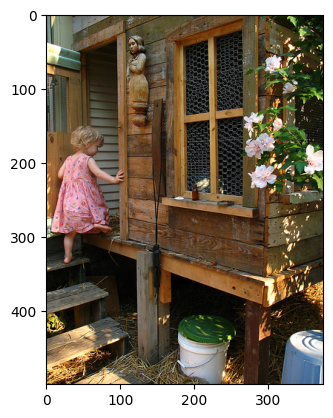

In [ ]:
IMG_PATH = 'Images/'
path = IMG_PATH+'1000268201_693b08cb0e.jpg'
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
print(path)

In [ ]:
#Write data into new file
with open('descriptions.txt', 'w') as f:
    f.write(str(descriptions))

In [ ]:
descriptions = None
with open('descriptions.txt', 'r', encoding='utf8') as f:
    descriptions = f.read()
json_string = descriptions.replace("'", "\"")
descriptions = json.loads(json_string)

In [ ]:
print(type(descriptions))

<class 'dict'>


In [ ]:
#Vocab
vocab = set()
for key in descriptions.keys():
    for sentence in descriptions[key]:
        vocab.update(sentence.split())

In [ ]:
#Total words across the file
total_words = []
for key in descriptions.keys():
    [total_words.append(i) for des in descriptions[key] for i in des.split()]

In [ ]:
#Filter words a/c to freq
THRESHOLD = 10
counter = collections.Counter(total_words)
freq_cnt = dict(counter)
sorted_freq_cnt = sorted(freq_cnt.items(), reverse=True, key = lambda x:x[1])
sorted_freq_cnt = [x for x in sorted_freq_cnt if int(x[1])>THRESHOLD]
total_words = [x[0] for x in sorted_freq_cnt]

In [ ]:
len(total_words)

1845

In [ ]:
#Training Data
train_file_data = readTextFile('Flickr_TextData/Flickr_8k.trainImages.txt')
test_file_data = readTextFile('Flickr_TextData/Flickr_8k.testImages.txt')

In [ ]:
train = train_file_data.split('\n')[:-1]
train = [row.split('.')[0] for row in train_file_data.split('\n')[:-1]]
test = [row.split('.')[0] for row in test_file_data.split('\n')[:-1]]

In [ ]:

train_descriptions = {}
for img_id in train:
    train_descriptions[img_id] = []
    for caption in descriptions[img_id]:
        cap_to_append = "<s> " + caption + " <e>"
        train_descriptions[img_id].append(cap_to_append)

In [ ]:
#Image Feature Extraction
model = ResNet50(weights='imagenet', input_shape=(224,224,3))
model.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model_new = Model(model.input, model.layers[-2].output)

In [ ]:
def preprocess_img(img):
    img = image.load_img(img, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis = 0)
    #Normalisation
    img = preprocess_input(img)
    return img

In [ ]:
def encode_img(img):
    img = preprocess_img(img)
    feature_vector = model_new.predict(img)
    # print(feature_vector.shape)
    feature_vector = feature_vector.reshape((-1,))
    # print(feature_vector.shape)
    return feature_vector

In [ ]:
# encoding_train = {}
# #image_id --> feature vector
# for ix, img_id in enumerate(train):
#     img_path = IMG_PATH+'/'+img_id+".jpg"
#     encoding_train[img_id] = encode_img(img_path)
#     if ix%500 ==0:
#         print(f"Step no {ix}")

In [ ]:
# #Store encodings in file
# with open ('encoded_train_features.pkl', 'wb') as f:
#     pickle.dump(encoding_train, f)

In [ ]:
# encoding_test = {}
# for ix, img_id in enumerate(test):
#     img_path = IMG_PATH+'/'+img_id+".jpg"
#     encoding_test[img_id] = encode_img(img_path)
#     if ix%200 ==0:
#         print(f"Step no {ix}")
# #Store encodings in file
# with open ('encoded_test_features.pkl', 'wb') as f:
#     pickle.dump(encoding_test, f)

In [ ]:
with open('encoded_train_features.pkl', 'rb') as f:
    encoding_train = pickle.load(f)
with open('encoded_test_features.pkl', 'rb') as f:
    encoding_test = pickle.load(f)


In [ ]:
#Data pre for captions
word2idx = {}
idx2word = {}
for i,word in enumerate(total_words):
    word2idx[word] = i+1 #reserve zero for sentence ends
    idx2word[i+1] = word
vocab_size = len(idx2word)
idx2word[vocab_size+1] = '<s>'
word2idx['<s>'] = vocab_size+1
idx2word[vocab_size+2] = '<e>'
word2idx['<e>'] = vocab_size+2
vocab_size = len(idx2word) #0 for sentence ends
vocab_size += 1

In [ ]:
max_len = 0
for key in train_descriptions.keys():
    for cap in train_descriptions[key]:
        max_len = max(max_len, len(cap.split()))
print(max_len)

35


## Data Generator

In [ ]:
# def data_generator(train_descriptions, encoding_train, word_to_idx, max_len, batch_size):
#     X1,X2,y = [],[],[]
#     n = 0
#     while True:
#         for key,desc_list in train_descriptions.items():
#             photo = encoding_train[key]
#             #Python practice/image_captioning/Images/1000268201_693b08cb0e.jpg
#             for cap in desc_list:
#                 seq = [word_to_idx[word]  for word in cap.split() if word in word_to_idx]
#                 for i in range(1,len(seq)):
#                     xi = seq[:i]
#                     yi = seq[i]
#                     #0 is padding word
#                     xi = pad_sequences([xi], maxlen= max_len, value=0, padding='post')[0]
#                     yi = to_categorical(yi, num_classes=vocab_size)

#                     X1.append(photo)
#                     X2.append(xi)
#                     y.append(yi)
#                     n += 1
#                 if n == batch_size:
#                     print("Example target (y):", np.array(y))
#                     yield ((np.array(X1), np.array(X2)), np.array(y))
#                     X1, X2, y =[],[],[]
#                     n=0

def data_generator(train_descriptions, encoding_train, word_to_idx, max_len, batch_size):
    while True:
        X1, X2, y = [], [], []
        for _ in range(batch_size):
            # Randomly select an image key
            key = random.choice(list(train_descriptions.keys()))
            photo = encoding_train[key]

            # Select a random caption for the chosen image
            desc_list = train_descriptions[key]
            caption = random.choice(desc_list)

            seq = [word_to_idx[word] for word in caption.split() if word in word_to_idx]
            for i in range(1, len(seq)):
                xi = seq[:i]
                xi = pad_sequences([xi], maxlen=max_len, value=0, padding='post')[0]
                yi = to_categorical(seq[i], num_classes=vocab_size)

                X1.append(photo)
                X2.append(xi)
                y.append(yi)

        yield ((np.array(X1), np.array(X2)), np.array(y))
        X1, X2, y = [], [], []  # Clear lists after each batch

## Word Embeddings

In [ ]:
embeddings_index = {}
with open('glove.6B.50d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embedding = np.array(values[1:], dtype = 'float')
        embeddings_index[word] = embedding

In [ ]:
emb_dim = 50
def get_embedding_matrix(emb_idx):
    matrix = np.zeros((vocab_size, emb_dim))
    for word,idx in word2idx.items():
        embedding_vector = emb_idx.get(word)
        if embedding_vector is not None:
            matrix[idx] = embedding_vector
    return matrix
embedding_matrix = get_embedding_matrix(embeddings_index)

## Model Architecture

In [ ]:
#image feature extractor model
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

#partial caption sequence model
inputs2 = Input(shape = (max_len,))
se1 = Embedding(vocab_size, emb_dim, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

#decoder feed forward model
decoder1 = add([fe2,se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

#merge the input models
model = Model(inputs = [inputs1, inputs2], outputs = outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 50)    │     92,400 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 35, 50)    │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 35)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    314,368 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1848)      │    474,936 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,472,040 (5.62 MB)

 Trainable params: 1,472,040 (5.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers[2].set_weights([embedding_matrix])
model.layers[2].trainable = False

In [ ]:
adam = Adam()

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer = adam)

## Model Training

In [ ]:
epochs = 30
batch_size = 3
steps = len(train_descriptions)//batch_size

In [ ]:
def train_model(epochs, model):
    for i in range(epochs):
        print(f"Epoch:- {i}")
        generator = data_generator(train_descriptions, encoding_train, word2idx, max_len, batch_size)
        model.fit(generator, epochs = 1, steps_per_epoch = steps, verbose = 1)
        model.save_weights(f'./saved_models/model_{i}.weights.h5')  # Updated file extension

In [ ]:
train_model(epochs, model)

Epoch:- 0
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 307s 149ms/step - loss: 5.1913
Epoch:- 1
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 296s 148ms/step - loss: 4.3763
Epoch:- 2
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 288s 144ms/step - loss: 4.1247
Epoch:- 3
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 260s 130ms/step - loss: 3.9913
Epoch:- 4
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 252s 126ms/step - loss: 3.8914
Epoch:- 5
 797/2000 ━━━━━━━━━━━━━━━━━━━━ 2:33 127ms/step - loss: 3.8841

KeyboardInterrupt: 

In [ ]:
load_model = model.load_weights('./saved_models/model_17.weights.h5')

In [ ]:
model.save('./saved_models/full_model.keras')

In [ ]:
model = load_model('./saved_models/full_model.keras')

TypeError: 'NoneType' object is not callable

In [ ]:
def predict_caption(photo):
  in_text = "<s>"
  for i in range(max_len):
    sequence = [word2idx[w] for w in in_text.split() if w in word2idx]
    sequence = pad_sequences([sequence], maxlen=max_len, padding='post')

    ypred = model.predict([photo,sequence])
    ypred = ypred.argmax() #Word with max prob(Greedy Sampling)///mean search
    word = idx2word[ypred]
    in_text += (' ' + word)

    if word == '<e>':
      break
  final_caption = in_text.split()[1:-1]
  final_caption = ' '.join(final_caption)
  return final_caption


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
two dogs are running through the snow


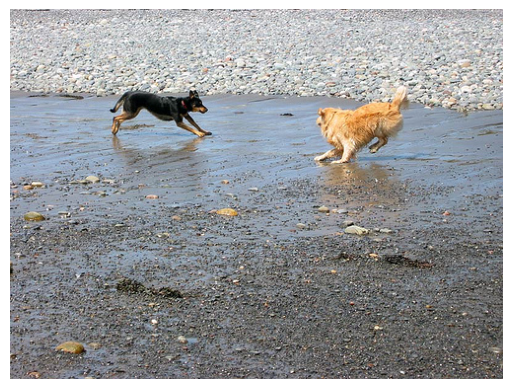

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
two men are playing soccer


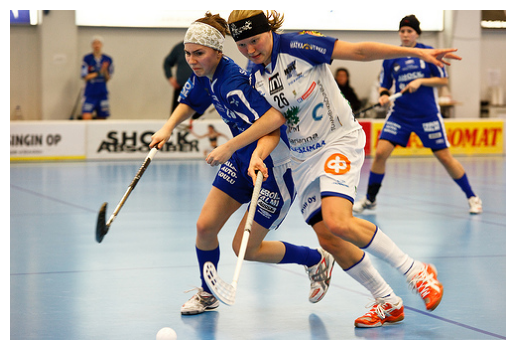

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
young girl in blue shirt is sitting on the floor


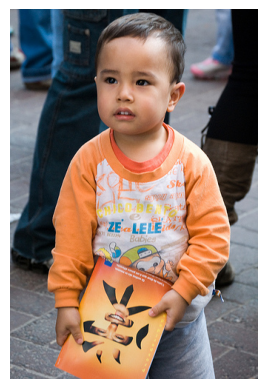

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
the white dog is running through the water


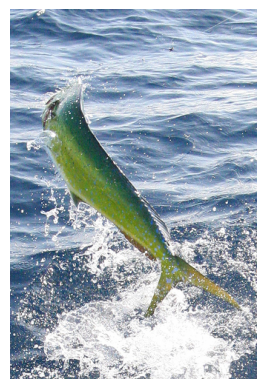

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
man in black shirt is standing on the street


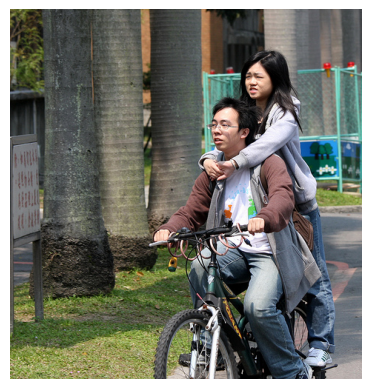

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
man in red shirt is sitting on the edge of the water


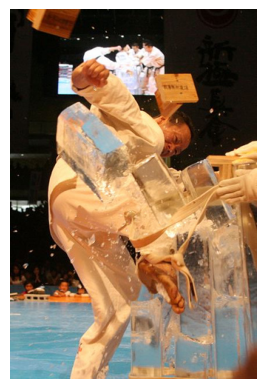

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
dog is running through the water


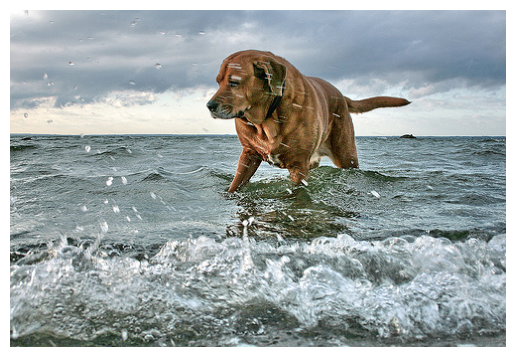

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
two children are playing in the grass


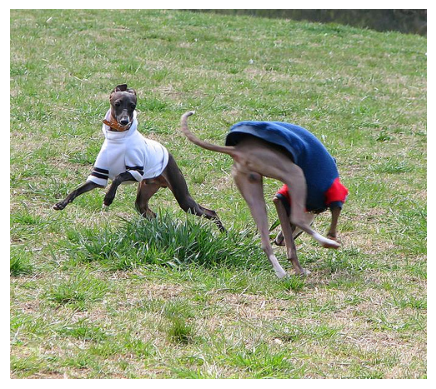

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
little girl in blue shirt is playing in the water


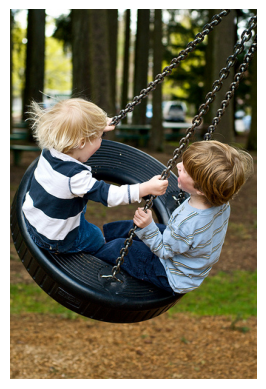

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
two children are playing in the water


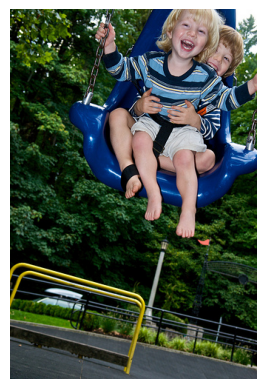

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
two people are standing on the street


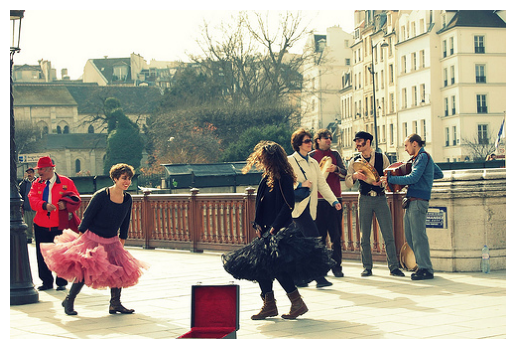

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
two men are playing soccer


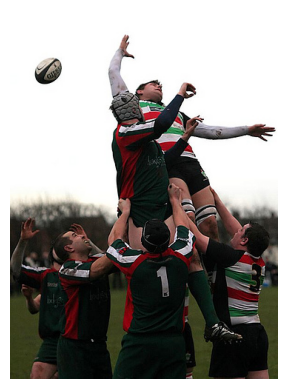

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━

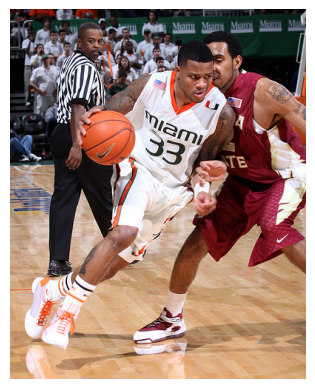

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
man in red shirt is riding bike on the road


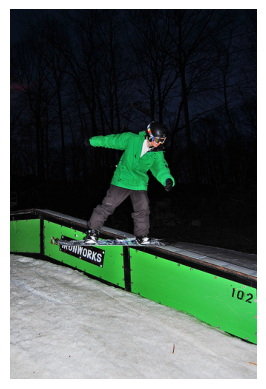

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
two dogs are running through the snow


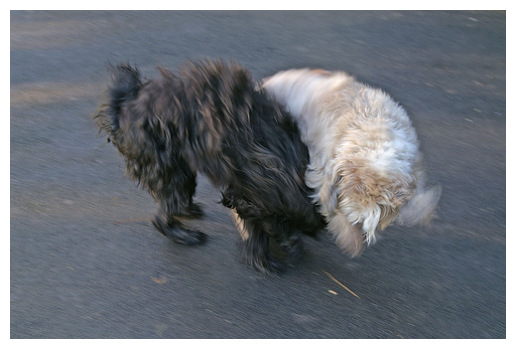

In [ ]:
#Pick random images and check
for i in range(15):
  no = np.random.randint(0,1000)
  img_name = list(encoding_test.keys())[no]
  photo_2048 = encoding_test[img_name].reshape((1,2048))

  i = plt.imread('Images'+'/'+img_name+'.jpg')
  caption = predict_caption(photo_2048)
  print(caption)
  plt.imshow(i)
  plt.axis('off')
  plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


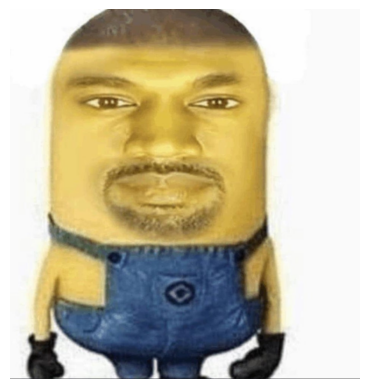

Caption for the image: man in black shirt is sitting on the camera


In [ ]:
def generate_caption_from_image(image_path):

    # Preprocess the image
    img = preprocess_img(image_path)

    # Extract features using the ResNet50 model
    photo_features = model_new.predict(img).reshape((1, 2048))

    # Generate the caption
    caption = predict_caption(photo_features)
    img = Image.open(image_path)  # Load the image using PIL
    plt.imshow(img)  # Display the image
    plt.axis('off')  # Hide axis
    plt.show()
    return caption

# Test the new function with a sample image
image_path = "./kanyinion.jpeg"  # Replace with your image file path
caption = generate_caption_from_image(image_path)
print(f"Caption for the image: {caption}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


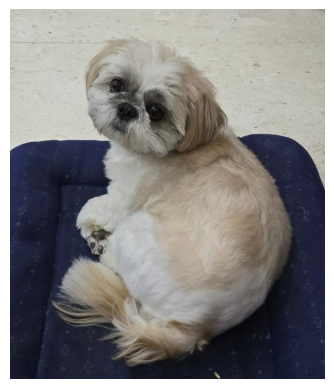

two dogs are playing in the grass


In [ ]:
caption = generate_caption_from_image("./muffoo.jpeg")
print(caption)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


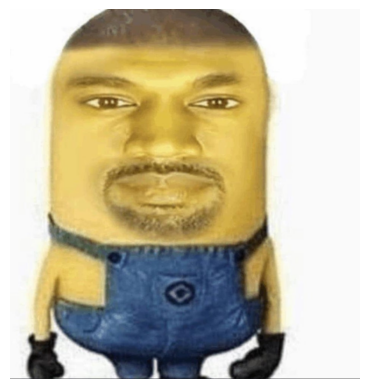

man in black shirt is sitting on the camera


In [ ]:
caption = generate_caption_from_image("./kanyinion.jpeg")
print(caption)